# FF++ Setup and Preprocessing — Fresh Explorer Version

This notebook is designed for your Northeastern Explorer session and your branch of:

`Cross-Generator-Generalization-in-Deepfake-Detection`

It corrects the problems encountered previously:

- always runs from the repository root;
- uses the existing `.venv` instead of `--user` installs;
- preserves the working CUDA-enabled PyTorch installation;
- checks storage before extraction;
- detects and resumes an interrupted ZIP extraction;
- verifies that all required FaceForensics++ categories exist;
- does not normalize or preprocess incomplete data;
- reads `crops.parquet` only after it has been successfully created.

Run each cell in order. Do not use **Run All** until you have successfully completed the package-installation and kernel-restart steps.

## 1. Set the repository root

In [1]:
from pathlib import Path
import os
import sys

REPO_ROOT = Path("/home/okonkwo.ob/Cross-Generator-Generalization-in-Deepfake-Detection")

if not REPO_ROOT.exists():
    raise FileNotFoundError(f"Repository not found: {REPO_ROOT}")

os.chdir(REPO_ROOT)

print("Working directory:", Path.cwd())
print("Python executable:", sys.executable)

if ".venv/bin/python" not in sys.executable:
    raise RuntimeError(
        "Select the 'Python (.venv - Deepfake)' kernel before continuing."
    )

Working directory: /home/okonkwo.ob/Cross-Generator-Generalization-in-Deepfake-Detection
Python executable: /home/okonkwo.ob/Cross-Generator-Generalization-in-Deepfake-Detection/.venv/bin/python


## 2. Verify CUDA and the GPU

In [2]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA build:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())

if not torch.cuda.is_available():
    raise RuntimeError("CUDA is unavailable in the selected kernel.")

print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.6.0+cu124
CUDA build: 12.4
CUDA available: True
GPU: Tesla P100-PCIE-12GB


## 3. Install the preprocessing dependencies

This installs packages into the active `.venv`. It does **not** reinstall PyTorch.

After this cell completes, choose **Kernel → Restart Kernel**, select
**Python (.venv - Deepfake)** again, and continue from section 4.

In [3]:
import subprocess
import sys

packages = [
    "numpy==1.26.4",
    "pandas==2.2.3",
    "pyarrow==18.1.0",
    "opencv-python-headless<5",
    "protobuf>=3.20.3,<5",
    "mediapipe",
    "kaggle",
]

subprocess.run(
    [sys.executable, "-m", "pip", "install", "--no-cache-dir", *packages],
    check=True,
)

print("Dependencies installed.")
print("Restart the kernel now, then continue with section 4.")

Dependencies installed.
Restart the kernel now, then continue with section 4.


## 4. Reconfirm the environment after restarting the kernel

In [4]:
from pathlib import Path
import os
import sys
import numpy as np
import pandas as pd
import pyarrow
import cv2
import torch

REPO_ROOT = Path("/home/okonkwo.ob/Cross-Generator-Generalization-in-Deepfake-Detection")
os.chdir(REPO_ROOT)

print("Working directory:", Path.cwd())
print("Python:", sys.executable)
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("PyArrow:", pyarrow.__version__)
print("OpenCV:", cv2.__version__)
print("PyTorch:", torch.__version__)
print("CUDA:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None")

if ".venv/bin/python" not in sys.executable:
    raise RuntimeError("Wrong kernel selected.")

if not torch.cuda.is_available():
    raise RuntimeError("CUDA is unavailable.")

Working directory: /home/okonkwo.ob/Cross-Generator-Generalization-in-Deepfake-Detection
Python: /home/okonkwo.ob/Cross-Generator-Generalization-in-Deepfake-Detection/.venv/bin/python
NumPy: 1.26.4
Pandas: 2.2.3
PyArrow: 18.1.0
OpenCV: 4.11.0
PyTorch: 2.6.0+cu124
CUDA: True
GPU: Tesla P100-PCIE-12GB


## 5. Run the repository environment check

In [5]:
import subprocess
import sys

subprocess.run([sys.executable, "check_env.py"], check=True)

Environment smoke test
[warn] Python 3.12.4 (3.11 is recommended)
[ ok ] torch 2.6.0+cu124
[ ok ] CUDA device: Tesla P100-PCIE-12GB (sm_60)
[ ok ] CUDA tensor op succeeded
[ ok ] torchvision 0.21.0, torchaudio 2.6.0
[ ok ] ffmpeg found on PATH
[ ok ] core packages import (9 checked)
[warn] 1 warning(s), nothing blocking.


CompletedProcess(args=['/home/okonkwo.ob/Cross-Generator-Generalization-in-Deepfake-Detection/.venv/bin/python', 'check_env.py'], returncode=0)

## 6. Create the required folders

In [6]:
from pathlib import Path

for folder in [
    Path("data/ffpp_kaggle"),
    Path("data/raw"),
    Path("data/processed"),
    Path("data/manifests"),
]:
    folder.mkdir(parents=True, exist_ok=True)
    print("Ready:", folder.resolve())

Ready: /home/okonkwo.ob/Cross-Generator-Generalization-in-Deepfake-Detection/data/ffpp_kaggle
Ready: /home/okonkwo.ob/Cross-Generator-Generalization-in-Deepfake-Detection/data/raw
Ready: /home/okonkwo.ob/Cross-Generator-Generalization-in-Deepfake-Detection/data/processed
Ready: /home/okonkwo.ob/Cross-Generator-Generalization-in-Deepfake-Detection/data/manifests


## 7. Check available storage

The archive and extracted videos require substantial space. This cell reports both
filesystem free space and your Explorer quota when the `quota` command is available.

In [7]:
from pathlib import Path
import shutil
import subprocess

usage = shutil.disk_usage(Path.cwd())
gb = 1024 ** 3

print(f"Filesystem total: {usage.total / gb:.1f} GB")
print(f"Filesystem used:  {usage.used / gb:.1f} GB")
print(f"Filesystem free:  {usage.free / gb:.1f} GB")

print("\nExplorer quota:")
subprocess.run(["bash", "-lc", "quota -s 2>/dev/null || echo 'quota command unavailable'"])

print("\nProject data usage:")
subprocess.run(["bash", "-lc", "du -sh data 2>/dev/null || true"])

Filesystem total: 261120.0 GB
Filesystem used:  148034.6 GB
Filesystem free:  113085.4 GB

Explorer quota:
quota command unavailable

Project data usage:
23G	data


CompletedProcess(args=['bash', '-lc', 'du -sh data 2>/dev/null || true'], returncode=0)

## 8. Verify Kaggle credentials

Upload your private API token to:

`/home/okonkwo.ob/.kaggle/kaggle.json`

Never paste the username or API key into the notebook.

In [8]:
from pathlib import Path
import os

KAGGLE_JSON = Path.home() / ".kaggle" / "kaggle.json"

if not KAGGLE_JSON.exists():
    raise FileNotFoundError(
        f"Kaggle credentials not found at {KAGGLE_JSON}"
    )

os.chmod(KAGGLE_JSON, 0o600)
print("Kaggle credentials found.")

Kaggle credentials found.


## 9. Download the Kaggle archive only when needed

The presence of a few extracted files is not treated as proof of a complete download.
The cell checks for the ZIP archive and expected MP4 files separately.

In [9]:
from pathlib import Path
import kaggle

STAGING = Path("data/ffpp_kaggle")
ARCHIVE = STAGING / "ff-c23.zip"

staged_mp4s = list(STAGING.rglob("*.mp4"))

print("Archive exists:", ARCHIVE.exists())
print("Extracted MP4 files currently present:", len(staged_mp4s))

if ARCHIVE.exists():
    print("Archive already exists; Kaggle download skipped.")
elif staged_mp4s:
    print(
        "Extracted videos exist but the ZIP is absent. "
        "The next sections will verify whether the extraction is complete."
    )
else:
    kaggle.api.authenticate()
    kaggle.api.dataset_download_files(
        "xdxd003/ff-c23",
        path=str(STAGING),
        unzip=False,
        quiet=False,
    )

    if not ARCHIVE.exists():
        zip_candidates = list(STAGING.glob("*.zip"))
        print("ZIP files found:", [p.name for p in zip_candidates])
        if len(zip_candidates) == 1:
            zip_candidates[0].rename(ARCHIVE)

    if not ARCHIVE.exists():
        raise FileNotFoundError("The Kaggle ZIP archive was not created.")

    print("Download complete:", ARCHIVE)

Archive exists: True
Extracted MP4 files currently present: 938
Archive already exists; Kaggle download skipped.


## 10. Inspect the archive

This verifies that the ZIP itself contains the required categories before extraction.

In [10]:
from pathlib import Path
from collections import Counter
import zipfile

ARCHIVE = Path("data/ffpp_kaggle/ff-c23.zip")
EXPECTED = ["original", "DeepFakes", "Face2Face", "FaceSwap", "NeuralTextures"]

if not ARCHIVE.exists():
    print("Archive is absent; verification will rely on already-extracted files.")
else:
    with zipfile.ZipFile(ARCHIVE, "r") as zf:
        bad_member = zf.testzip()
        if bad_member:
            raise RuntimeError(f"Corrupt ZIP member detected: {bad_member}")

        members = zf.infolist()
        counts = Counter()

        for member in members:
            normalized = member.filename.replace("\\", "/")
            if normalized.lower().endswith(".mp4"):
                parts_lower = [part.lower() for part in normalized.split("/")]
                for method in EXPECTED:
                    if method.lower() in parts_lower:
                        counts[method] += 1
                        break

    print("Required MP4 counts inside ZIP:")
    for method in EXPECTED:
        print(f"{method}: {counts[method]}")

    missing = [method for method in EXPECTED if counts[method] == 0]
    if missing:
        raise RuntimeError(
            f"The ZIP does not contain these required categories: {missing}"
        )

Required MP4 counts inside ZIP:
original: 1000
DeepFakes: 1000
Face2Face: 1000
FaceSwap: 1000
NeuralTextures: 1000


## 11. Resume an interrupted extraction

This cell compares each ZIP member with the existing extracted file. It extracts only
missing or incomplete files, so an interrupted extraction can continue without starting
from zero.

A disk-quota error means you must free storage before rerunning this cell.

In [12]:
from pathlib import Path
import zipfile

STAGING = Path("data/ffpp_kaggle")
ARCHIVE = STAGING / "ff-c23.zip"

if not ARCHIVE.exists():
    print("No ZIP archive is present. Skipping extraction.")
else:
    extracted = 0
    already_complete = 0

    try:
        with zipfile.ZipFile(ARCHIVE, "r") as zf:
            file_members = [m for m in zf.infolist() if not m.is_dir()]
            total = len(file_members)

            for index, member in enumerate(file_members, start=1):
                destination = STAGING / member.filename

                if destination.exists() and destination.stat().st_size == member.file_size:
                    already_complete += 1
                    continue

                destination.parent.mkdir(parents=True, exist_ok=True)
                zf.extract(member, STAGING)
                extracted += 1

                if extracted % 100 == 0:
                    print(
                        f"Extracted this run: {extracted}; "
                        f"already complete: {already_complete}; "
                        f"archive entries checked: {index}/{total}"
                    )

    except OSError as exc:
        if getattr(exc, "errno", None) == 122:
            raise RuntimeError(
                "Disk quota exceeded during extraction. Free space, then rerun this cell; "
                "it will resume from completed files."
            ) from exc
        raise

    print("Extraction pass complete.")
    print("Newly extracted files:", extracted)
    print("Already-complete files:", already_complete)

Extracted this run: 100; already complete: 937; archive entries checked: 1037/7010
Extracted this run: 200; already complete: 937; archive entries checked: 1137/7010
Extracted this run: 300; already complete: 937; archive entries checked: 1237/7010
Extracted this run: 400; already complete: 937; archive entries checked: 1337/7010
Extracted this run: 500; already complete: 937; archive entries checked: 1437/7010
Extracted this run: 600; already complete: 937; archive entries checked: 1537/7010
Extracted this run: 700; already complete: 937; archive entries checked: 1637/7010
Extracted this run: 800; already complete: 937; archive entries checked: 1737/7010
Extracted this run: 900; already complete: 937; archive entries checked: 1837/7010
Extracted this run: 1000; already complete: 937; archive entries checked: 1937/7010
Extracted this run: 1100; already complete: 937; archive entries checked: 2037/7010
Extracted this run: 1200; already complete: 937; archive entries checked: 2137/7010
E

## 12. Verify the extracted FaceForensics++ categories

Do not continue unless every required category has MP4 files.

In [13]:
from pathlib import Path

STAGING = Path("data/ffpp_kaggle")
EXPECTED = ["original", "DeepFakes", "Face2Face", "FaceSwap", "NeuralTextures"]

counts = {}

for method in EXPECTED:
    method_dirs = [
        p for p in STAGING.rglob("*")
        if p.is_dir() and p.name.lower() == method.lower()
    ]
    counts[method] = sum(
        len(list(folder.rglob("*.mp4")))
        for folder in method_dirs
    )
    print(f"{method}: {counts[method]}")

missing = [method for method, count in counts.items() if count == 0]

if missing:
    raise RuntimeError(
        "Extraction is incomplete. Missing required categories: "
        + ", ".join(missing)
        + ". Rerun the resumable extraction cell after resolving storage issues."
    )

print("All required categories are present.")

original: 1000
DeepFakes: 1000
Face2Face: 1000
FaceSwap: 1000
NeuralTextures: 1000
All required categories are present.


## 13. Normalize into `data/raw/<method>/`

The repository script moves the recognized categories into its canonical layout.
Extra folders such as `DeepFakeDetection` are ignored.

In [14]:
from pathlib import Path
import subprocess
import sys

required_raw = ["real", "DeepFakes", "Face2Face", "FaceSwap", "NeuralTextures"]
existing_raw_counts = {
    method: len(list((Path("data/raw") / method).rglob("*.mp4")))
    for method in required_raw
}

if all(count > 0 for count in existing_raw_counts.values()):
    print("Canonical raw-data folders already exist; normalization skipped.")
    print(existing_raw_counts)
else:
    subprocess.run(
        [
            sys.executable,
            "data/download_ffpp.py",
            "--route", "local",
            "--source-dir", "data/ffpp_kaggle",
            "--link-mode", "move",
        ],
        check=True,
    )

print("\nCanonical raw-data counts:")
for method in required_raw:
    count = len(list((Path("data/raw") / method).rglob("*.mp4")))
    print(f"{method}: {count}")

real            placed 1000, skipped(existing) 0
DeepFakes       placed 1000, skipped(existing) 0
Face2Face       placed 1000, skipped(existing) 0
FaceSwap        placed 1000, skipped(existing) 0
NeuralTextures  placed 1000, skipped(existing) 0
done: real=1000, DeepFakes=1000, Face2Face=1000, FaceSwap=1000, NeuralTextures=1000  total 5000  provenance: data/PROVENANCE.md

Canonical raw-data counts:
real: 1000
DeepFakes: 1000
Face2Face: 1000
FaceSwap: 1000
NeuralTextures: 1000


## 14. Validate the canonical raw dataset

In [15]:
from pathlib import Path
import subprocess
import sys

required_raw = ["real", "DeepFakes", "Face2Face", "FaceSwap", "NeuralTextures"]
counts = {
    method: len(list((Path("data/raw") / method).rglob("*.mp4")))
    for method in required_raw
}

missing = [method for method, count in counts.items() if count == 0]
if missing:
    raise RuntimeError(f"Canonical raw dataset is incomplete: {missing}")

subprocess.run(
    [
        sys.executable,
        "data/inventory_ffpp.py",
        "--raw", "data/raw",
        "--out", "data/manifests/ff_inventory.csv",
    ],
    check=True,
)

print("Inventory saved to data/manifests/ff_inventory.csv")

method          expected  found  corrupt status
real                1000   1000        0 OK
DeepFakes           1000   1000        0 OK
Face2Face           1000   1000        0 OK
FaceSwap            1000   1000        0 OK
NeuralTextures      1000   1000        0 OK
TOTAL               5000   5000        0 OK
wrote data/manifests/ff_inventory.csv
OK: all methods complete and readable
Inventory saved to data/manifests/ff_inventory.csv


## 15. Prepare the crop cache

Stale manifests are removed only when no crop files exist.

In [16]:
from pathlib import Path

crop_files = list(Path("data/processed").rglob("*.npy"))

if crop_files:
    print(f"Existing crop files: {len(crop_files)}. Resume mode will preserve them.")
else:
    for stale in [
        Path("data/manifests/detection_log.csv"),
        Path("data/manifests/crops.parquet"),
    ]:
        if stale.exists():
            stale.unlink()
            print("Removed stale file:", stale)

    print("No existing crop cache; preprocessing will begin from scratch.")

No existing crop cache; preprocessing will begin from scratch.


## 16. Run preprocessing

In [17]:
from pathlib import Path
import subprocess
import sys

raw_mp4s = list(Path("data/raw").rglob("*.mp4"))
if not raw_mp4s:
    raise FileNotFoundError("No raw MP4 files were found.")

subprocess.run(
    [
        sys.executable,
        "data/preprocess.py",
        "--raw", "data/raw",
        "--out", "data/processed",
        "--manifest", "data/manifests/crops.parquet",
        "--detect-log", "data/manifests/detection_log.csv",
        "--resume",
    ],
    check=True,
)

print("Preprocessing command completed.")

INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1784506850.254959 1915850 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
real:   0%|          | 0/1000 [00:00<?, ?it/s]

downloading face detector model to /home/okonkwo.ob/.cache/ffpp_preprocess/blaze_face_short_range.tflite



DeepFakes:   0%|          | 0/1000 [00:00<?, ?it/s]

real done



Face2Face:   0%|          | 0/1000 [00:00<?, ?it/s]

...

Face2Face done



NeuralTextures:   0%|          | 0/1000 [00:00<?, ?it/s]

FaceSwap done



methods: 100%|██████████| 5/5 [5:20:03<00:00, 3840.73s/it]         


NeuralTextures done
wrote data/manifests/crops.parquet 97262 crops
wrote data/manifests/detection_log.csv 5000 clips
detection success-rate summary (real vs fake, threshold 0.50):
  real (label 0): clips=1000   mean_rate=0.9726   below_low=27
  fake (label 1): clips=4000   mean_rate=0.9726   below_low=106
  per-method mean detection_rate:
    real            0.9726
    DeepFakes       0.9717
    Face2Face       0.9728
    FaceSwap        0.9728
    NeuralTextures  0.9732
Preprocessing command completed.


## 17. Verify and inspect the crop manifest

Manifest exists: True
Crop files: 97262
Total manifest rows: 97262

Rows by method:
method
DeepFakes         19433
Face2Face         19455
FaceSwap          19457
NeuralTextures    19465
real              19452
dtype: int64


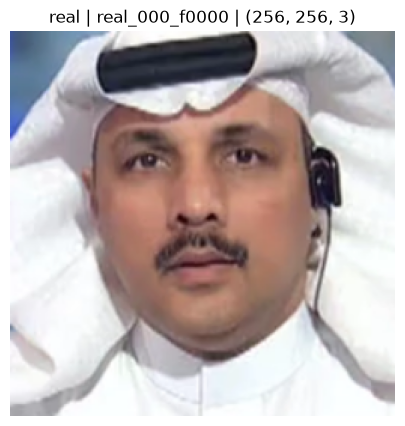

In [18]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

manifest = Path("data/manifests/crops.parquet")
crop_files = list(Path("data/processed").rglob("*.npy"))

print("Manifest exists:", manifest.exists())
print("Crop files:", len(crop_files))

if not manifest.exists():
    raise FileNotFoundError(
        "Preprocessing did not create data/manifests/crops.parquet."
    )

if not crop_files:
    raise RuntimeError("No crop files were created.")

m = pd.read_parquet(manifest)

print("Total manifest rows:", len(m))
print("\nRows by method:")
print(m.groupby("method").size())

if m.empty:
    raise RuntimeError("The manifest is empty.")

row = m.iloc[0]
crop_path = Path(row["path"])
if not crop_path.is_absolute():
    crop_path = Path.cwd() / crop_path

if not crop_path.exists():
    raise FileNotFoundError(f"Missing crop file: {crop_path}")

img = np.load(crop_path)

plt.figure(figsize=(5, 5))
plt.imshow(img)
plt.axis("off")
plt.title(f"{row['method']} | {row['crop_id']} | {img.shape}")
plt.show()

## 18. Final status

In [19]:
from pathlib import Path
import pandas as pd

manifest = Path("data/manifests/crops.parquet")
m = pd.read_parquet(manifest)

print("PREPROCESSING READY")
print("Manifest:", manifest.resolve())
print("Manifest rows:", len(m))
print("Next notebook: experiments/01_train.ipynb")
print("Run name: efficientnet_holdout-face2face")

PREPROCESSING READY
Manifest: /home/okonkwo.ob/Cross-Generator-Generalization-in-Deepfake-Detection/data/manifests/crops.parquet
Manifest rows: 97262
Next notebook: experiments/01_train.ipynb
Run name: efficientnet_holdout-face2face
